In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn

In [5]:
tf.random.set_seed(7)

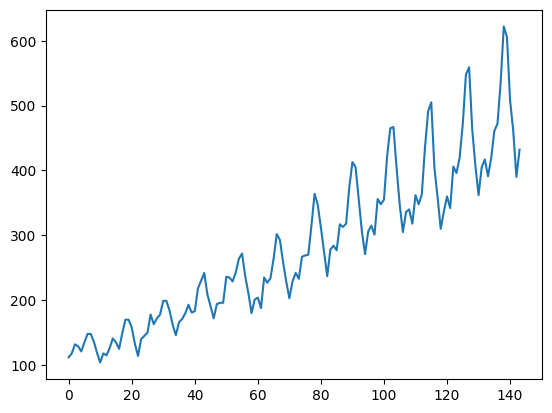

In [6]:
dataframe = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv', usecols=[1], engine='python')
df = dataframe.values
df = df.astype('float32')
plt.plot(df)
plt.show()

In [7]:
scaler = MinMaxScaler(feature_range=(0,1))
df = scaler.fit_transform(df)
df[: 5]
df.shape

(144, 1)

In [8]:
train_size = int(len(df) * 0.67)
test_size = len(df) - train_size

train, test = df[0:train_size, :], df[train_size:len(df), :]
print(type(train), len(test))

<class 'numpy.ndarray'> 48


In [9]:
look_back = 1 
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

trainX, trainY = create_dataset(dataset=train, look_back=look_back)
testX, testY = create_dataset(test, look_back=look_back)


In [10]:
# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [11]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

Epoch 1/100


c:\Users\sou1n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 - 1s - 15ms/step - loss: 0.0456
Epoch 2/100
94/94 - 0s - 2ms/step - loss: 0.0220
Epoch 3/100
94/94 - 0s - 1ms/step - loss: 0.0161
Epoch 4/100
94/94 - 0s - 1ms/step - loss: 0.0146
Epoch 5/100
94/94 - 0s - 1ms/step - loss: 0.0136
Epoch 6/100
94/94 - 0s - 2ms/step - loss: 0.0127
Epoch 7/100
94/94 - 0s - 2ms/step - loss: 0.0118
Epoch 8/100
94/94 - 0s - 1ms/step - loss: 0.0109
Epoch 9/100
94/94 - 0s - 1ms/step - loss: 0.0101
Epoch 10/100
94/94 - 0s - 1ms/step - loss: 0.0092
Epoch 11/100
94/94 - 0s - 1ms/step - loss: 0.0084
Epoch 12/100
94/94 - 0s - 1ms/step - loss: 0.0076
Epoch 13/100
94/94 - 0s - 1ms/step - loss: 0.0069
Epoch 14/100
94/94 - 0s - 2ms/step - loss: 0.0062
Epoch 15/100
94/94 - 0s - 2ms/step - loss: 0.0055
Epoch 16/100
94/94 - 0s - 1ms/step - loss: 0.0049
Epoch 17/100
94/94 - 0s - 1ms/step - loss: 0.0044
Epoch 18/100
94/94 - 0s - 2ms/step - loss: 0.0039
Epoch 19/100
94/94 - 0s - 2ms/step - loss: 0.0035
Epoch 20/100
94/94 - 0s - 1ms/step - loss: 0.0032
Epoch 21/100
94/94 -

In [12]:
# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Train Score: 23.07 RMSE
Test Score: 48.11 RMSE


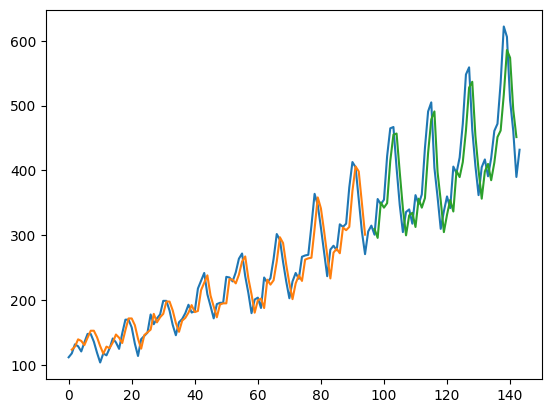

In [13]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(df)-1, :] = testPredict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [14]:
x = np.linspace(0, 100, 1000)
data = np.sin(x)
data.shape

(1000,)

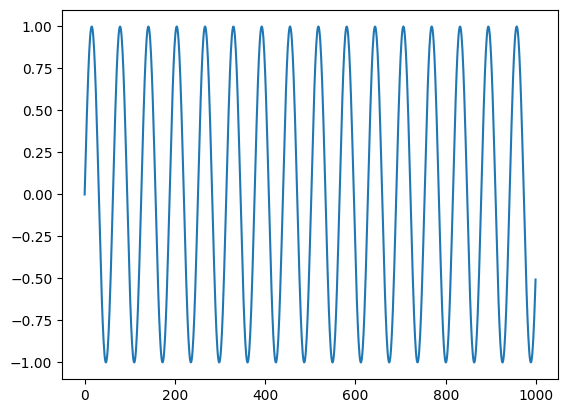

In [15]:
plt.plot(data)
plt.show()

In [122]:
def create_sequences(data, seq_len):
    x = []
    y = []
    length = len(data)

    for i in range(length-seq_len):
        x.append(data[i: i+seq_len])
        y.append(data[i+seq_len])

    x = np.array(x)
    y = np.array(y)

    x = x.reshape(x.shape[0], x.shape[1], 1)
    y = y.reshape(x.shape[0], 1)
    return x, y 


In [123]:
x_train, y_train = create_sequences(data, 30)

In [124]:
class SimpleLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.linear = nn.Linear(32, 1)
    
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        last = output[:, -1, :]
        pred = self.linear(last)

        return pred


In [125]:
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)


In [126]:
y_train.shape

torch.Size([970, 1])

In [163]:
model = SimpleLSTM()
criteria = nn.MSELoss()
optimizer = torch.optim.Adam( model.parameters(), lr= 0.001 )

for epoch in range(100):

    optimizer.zero_grad()

    predictions = model(x_train)

    loss = criteria(predictions, y_train)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch} loss = {loss.item()}")


epoch 0 loss = 0.5250966548919678
epoch 10 loss = 0.46499764919281006
epoch 20 loss = 0.4033735990524292
epoch 30 loss = 0.32340142130851746
epoch 40 loss = 0.21677570044994354
epoch 50 loss = 0.14540500938892365
epoch 60 loss = 0.07734183222055435
epoch 70 loss = 0.025753257796168327
epoch 80 loss = 0.008880779147148132
epoch 90 loss = 0.006308722775429487


In [164]:
model.eval()

SimpleLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [165]:
with torch.no_grad():
    predictions = model(x_train)


In [166]:
predictions = predictions.numpy()
actual = y_train.numpy()

predictions.shape

(970, 1)

In [167]:
actual.shape

(970, 1)

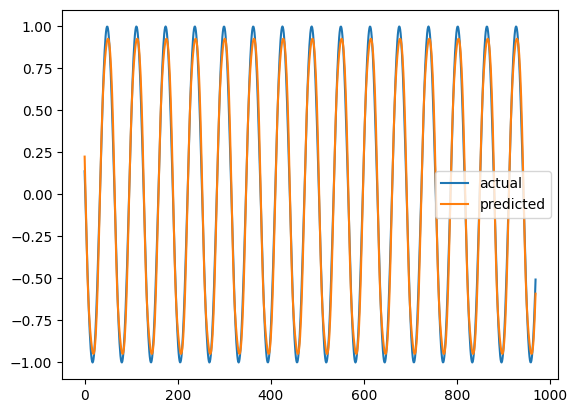

In [168]:
plt.plot(actual, label = "actual")
plt.plot(predictions, label= "predicted")
plt.legend()
plt.show()
